## Multiple Linear Regression

In [ ]:
"""
Multiple Linear Regression

Simple Linear Regression:
y = b0 + b1*x1

Multiple Linear Regression:
y = b0 + b1*x1 + b2*x2 + ... + bn*xn

Used when target depends on multiple features.
"""

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [5]:
# Load Dataset

housing = fetch_california_housing()

In [ ]:
X = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

y = housing.target

In [7]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [8]:
# Dataset Info

print("Feature Shape", X.shape)
print("Target Shape", y.shape)

Feature Shape (20640, 8)
Target Shape (20640,)


In [10]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split (
    X, 
    y,
    test_size = 0.2,
    random_state=42
)

In [11]:
print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


In [12]:
# Model Training

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
coeff = pd.DataFrame(
    {
    "Feature" : X.columns,
    "coeff" : model.coef_
    }
)
coeff

,Feature,coeff
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


In [18]:
print("Intercept:", model.intercept_)

Intercept: -37.02327770606416


In [26]:
y_pred = model.predict(X_test)
y_pred[:10]

array([0.71912284, 1.76401657, 2.70965883, 2.83892593, 2.60465725,
       2.01175367, 2.64550005, 2.16875532, 2.74074644, 3.91561473])

In [29]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 0.5332001304956555
MSE : 0.5558915986952442
R2 Score : 0.575787706032451


In [31]:
# Actual vs Predicted

comparison = pd.DataFrame({
    "Actual" : y_test[:20],
    "Predicted": y_pred[:20] 
})

comparison

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


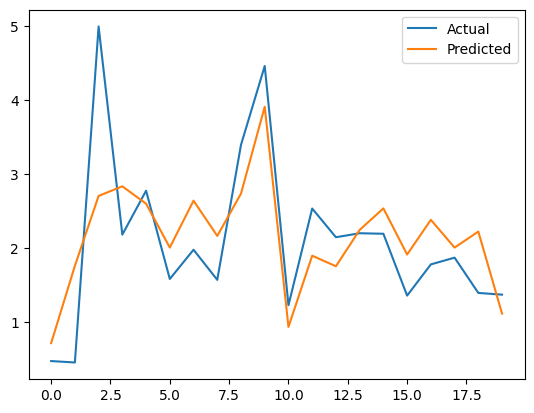

In [43]:
plt.plot(y_test[:20], label="Actual")
plt.plot(y_pred[:20], label="Predicted")

plt.legend()
plt.show()

##### """
Key Learnings

1. Multiple Linear Regression uses multiple features.

2. Formula:

y = b0 + b1*x1 + b2*x2 + ... + bn*xn

3. We use fit() to train.

4. We use predict() for prediction.

5. Evaluation:
   - MAE
   - MSE
   - RMSE
   - R2 Score
"""